In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Rescaling, Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy
from keras.utils import image_dataset_from_directory
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [ ]:
# Organize data into train, valid, test dirs
os.chdir('sample_data/PetImages/')
if os.path.isdir('train/dog') is False:
  os.makedirs('train/dog')
  os.makedirs('train/cat')
  os.makedirs('valid/dog')
  os.makedirs('valid/cat')
  os.makedirs('test/dog')
  os.makedirs('test/cat')

  for c in random.sample(glob.glob('Dog/*'), 500):
    shutil.move(c, 'train/dog')
  for c in random.sample(glob.glob('Cat/*'), 500):
    shutil.move(c, 'train/cat')

  for c in random.sample(glob.glob('Dog/*'), 100):
    shutil.move(c, 'valid/dog')
  for c in random.sample(glob.glob('Cat/*'), 100):
    shutil.move(c, 'valid/cat')


  for c in random.sample(glob.glob('Dog/*'), 50):
    shutil.move(c, 'test/dog')
  for c in random.sample(glob.glob('Cat/*'), 50):
    shutil.move(c, 'test/cat')

os.chdir('../../')

In [ ]:
train_path = os.path.join(os.getcwd(), 'sample_data/PetImages/train')
valid_path = os.path.join(os.getcwd(), 'sample_data/PetImages/valid')
test_path = os.path.join(os.getcwd(), 'sample_data/PetImages/test')

In [ ]:
train_path
valid_path
test_path

'/content/sample_data/PetImages/test'

In [ ]:
os.getcwd()

'/content'

In [ ]:
train_batches = image_dataset_from_directory(train_path, labels='inferred', label_mode='int', image_size=(224,224), batch_size=10, class_names=['cat', 'dog'])
valid_batches = image_dataset_from_directory(valid_path, labels='inferred', label_mode='int', image_size=(224,224), batch_size=10, class_names=['cat', 'dog'])
test_batches = image_dataset_from_directory(test_path, labels='inferred', label_mode='int', image_size=(224,224), batch_size=10, shuffle=False, class_names=['cat', 'dog'])

Found 1000 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [ ]:
train_batches.class_names
print(train_batches.class_names)
print(valid_batches.class_names)
print(test_batches.class_names)

['cat', 'dog']
['cat', 'dog']
['cat', 'dog']


In [ ]:
train_file_paths = train_batches.file_paths
valid_file_paths = valid_batches.file_paths
test_file_paths = test_batches.file_paths
print(f"Total number of images found: {len(train_file_paths)}")
print(f"Total number of images found: {len(valid_file_paths)}")
print(f"Total number of images found: {len(test_file_paths)}")



Total number of images found: 1000
Total number of images found: 200
Total number of images found: 100


In [ ]:
from PIL import Image

In [ ]:
# verifying all images all are not corrupted

for i in test_file_paths:
  with Image.open(i) as img:
    try:
      img.verify()
    except:
      print(i, 'invalid image')

# **Build and train a CNN**

In [ ]:
model = Sequential([
    Rescaling(scale=1./255, input_shape=(224, 224, 3)),
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=(2,2), strides=2),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size=(2,2), strides=2),
    Flatten(),
    Dense(units=2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       401,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,802 (1.61 MB)

 Trainable params: 420,802 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x=train_batches, validation_data=valid_batches, epochs=10, verbose=2)

Epoch 1/10
100/100 - 88s - 882ms/step - accuracy: 0.4950 - loss: 0.8900 - val_accuracy: 0.5000 - val_loss: 0.6819
Epoch 2/10
100/100 - 141s - 1s/step - accuracy: 0.5920 - loss: 0.6769 - val_accuracy: 0.5700 - val_loss: 0.6752
Epoch 3/10
100/100 - 85s - 848ms/step - accuracy: 0.7060 - loss: 0.5931 - val_accuracy: 0.5300 - val_loss: 0.7280
Epoch 4/10
100/100 - 148s - 1s/step - accuracy: 0.8060 - loss: 0.4446 - val_accuracy: 0.6050 - val_loss: 0.7670
Epoch 5/10
100/100 - 89s - 888ms/step - accuracy: 0.8900 - loss: 0.2707 - val_accuracy: 0.6100 - val_loss: 1.0013
Epoch 6/10
100/100 - 88s - 880ms/step - accuracy: 0.9540 - loss: 0.1485 - val_accuracy: 0.5850 - val_loss: 1.0842
Epoch 7/10
100/100 - 140s - 1s/step - accuracy: 0.9800 - loss: 0.0873 - val_accuracy: 0.5550 - val_loss: 1.4084
Epoch 8/10
100/100 - 87s - 870ms/step - accuracy: 0.9870 - loss: 0.0420 - val_accuracy: 0.5950 - val_loss: 1.3994
Epoch 9/10
100/100 - 98s - 980ms/step - accuracy: 0.9960 - loss: 0.0141 - val_accuracy: 0.5900

## **Predict**

In [ ]:
for img, label in test_batches:
  print(label)

test_imgs, test_labels = next(iter(test_batches))



print("dtype:", test_imgs.dtype)
print("shape:", test_imgs.shape)            # (B, H, W, C)?
print("min/max:", tf.reduce_min(test_imgs).numpy(), tf.reduce_max(test_imgs).numpy())
print("one sample shape:", test_imgs[9].shape)

img = tf.cast(tf.clip_by_value(test_imgs[8], 0, 255), tf.uint8)
plt.imshow(img.numpy())
plt.axis('off')

print(test_labels)
print(test_batches.class_names)


NameError: name 'test_batches' is not defined

In [ ]:
predictions = model.predict(x=test_batches, verbose=0)
predictions

array([[9.99255180e-01, 7.44864752e-04],
       [9.99775410e-01, 2.24528936e-04],
       [9.95882392e-01, 4.11760900e-03],
       [9.99999940e-01, 3.56946006e-09],
       [9.98718798e-01, 1.28114002e-03],
       [8.21793675e-01, 1.78206295e-01],
       [9.99151528e-01, 8.48431082e-04],
       [9.99449849e-01, 5.50132187e-04],
       [8.86174083e-01, 1.13825962e-01],
       [7.83031940e-01, 2.16968045e-01],
       [6.77203476e-01, 3.22796494e-01],
       [9.90633190e-01, 9.36677773e-03],
       [6.12082005e-01, 3.87917995e-01],
       [1.93226993e-01, 8.06773067e-01],
       [6.92475960e-03, 9.93075192e-01],
       [3.18653602e-03, 9.96813476e-01],
       [9.99980867e-01, 1.90218052e-05],
       [9.99999583e-01, 3.80983607e-07],
       [9.58767831e-01, 4.12321985e-02],
       [2.25370020e-01, 7.74630010e-01],
       [9.13110912e-01, 8.68891403e-02],
       [3.90037239e-01, 6.09962761e-01],
       [9.58617687e-01, 4.13822196e-02],
       [9.98021603e-01, 1.97842764e-03],
       [3.154672

In [ ]:
np.round(predictions)

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.

In [ ]:
np.argmax(predictions, axis=-1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
print(test_batches.unbatch())

<_UnbatchDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>


In [ ]:
# creating the confusion matrix
# test_labels = np.array([])

test_labels = np.array([])
for image, labels in test_batches:
  test_labels = np.append(test_labels, labels)
  # print(test_labels)

# img, labels = test_batches.unbatch()

In [ ]:
print(test_labels[0])
print(np.argmax(predictions[0], axis=-1))

tf.Tensor(0, shape=(), dtype=int32)
0


In [ ]:
cm = confusion_matrix(y_true=test_labels, y_pred=np.argmax(predictions, axis=-1))

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):


  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()

  tick_marks = np.arange(len(classes))
  print(tick_marks, classes)
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)


  if normalize:
    cm=cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print('Normalized confusion matrix')
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  thresh = cm.max() / 2

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')


[[37 13]
 [26 24]]
[0 1] ['cat', 'dog']
Confusion matrix, without normalization
[[37 13]
 [26 24]]


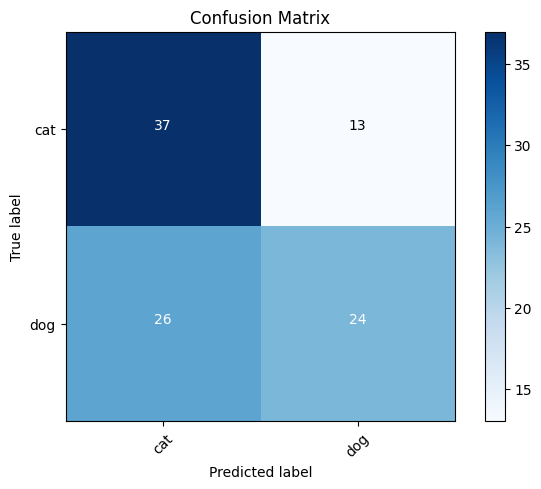

In [ ]:
cm_plot_lables = ['cat', 'dog']
print(cm)
plot_confusion_matrix(cm=cm, classes=cm_plot_lables, title='Confusion Matrix')

In [ ]:
model.save('models/first_cnn_cat_and-dog.h5')